In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv('./datasets/iris.csv')
print(df.shape)
print(df.isnull().sum())
df.head()

(150, 6)
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
x = df.drop(columns=['Species']).values
y = df['Species'].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [12]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)

In [13]:
model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [14]:
y_pred = model.predict(x_test)
accuracy_score(y_test, y_pred)

1.0

########################################################<br>
\# Graph<br>
########################################################

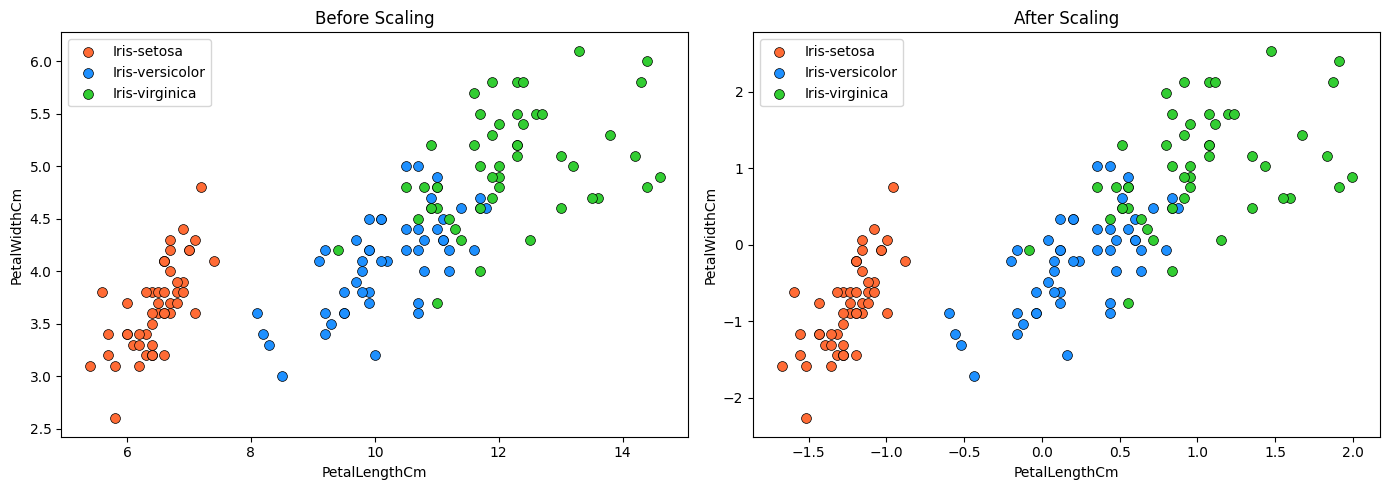

In [17]:
x2_scaled = StandardScaler().fit_transform(x2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in zip(axes, [x2, x2_scaled], ['Before Scaling', 'After Scaling']):
    for cls, color in palette.items():
        mask = y2 == cls
        ax.scatter(data[mask, 0], data[mask, 1], c=color, label=cls, edgecolors='k', linewidths=0.5, s=50)
    ax.set_xlabel('PetalLengthCm')
    ax.set_ylabel('PetalWidthCm')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

/home/boseok/workspace/ml/lib/python3.14/site-packages/sklearn/inspection/_plot/decision_boundary.py:225: UserWarning: 'colors' is ignored in favor of 'multiclass_colors' in the multiclass case when the response method is 'decision_function' or 'predict_proba'.
  warnings.warn(


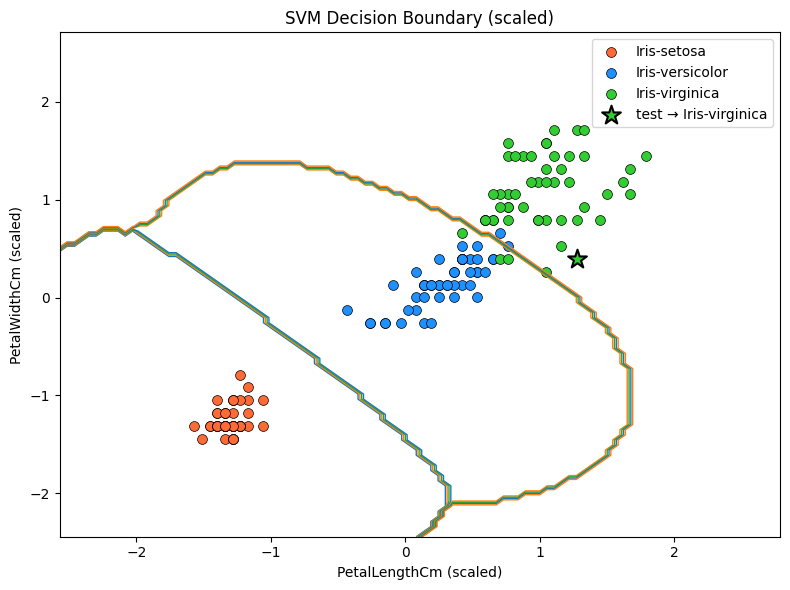

In [ ]:
from sklearn.inspection import DecisionBoundaryDisplay

x2 = df[['PetalLengthCm', 'PetalWidthCm']].values
y2 = df['Species'].values

scaler2 = StandardScaler().fit(x2)
x2_scaled = scaler2.transform(x2)

palette = {'Iris-setosa': '#FF6B35', 'Iris-versicolor': '#1E90FF', 'Iris-virginica': '#32CD32'}

svm_2d = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_2d.fit(x2_scaled, y2)

# --- Test point
test_point = [[6.0, 1.5]]
test_scaled = scaler2.transform(test_point)
predicted = svm_2d.predict(test_scaled)[0]
# ---

fig, ax = plt.subplots(figsize=(8, 6))

for cls, color in palette.items():
    mask = y2 == cls
    ax.scatter(x2_scaled[mask, 0], x2_scaled[mask, 1], c=color, label=cls, edgecolors='k', linewidths=0.5, s=50)

DecisionBoundaryDisplay.from_estimator(svm_2d, x2_scaled, plot_method='contour', colors='black', linewidths=1.0, ax=ax)

ax.scatter(test_scaled[0, 0], test_scaled[0, 1],
           c=palette[predicted], s=200, marker='*',
           edgecolors='black', linewidths=1.5, zorder=5, label=f'test → {predicted}')

ax.set_xlabel('PetalLengthCm (scaled)')
ax.set_ylabel('PetalWidthCm (scaled)')
ax.set_title('SVM Decision Boundary (scaled)')
ax.legend()
plt.tight_layout()
plt.show()